In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from models import SimpleCNN, trainset, testset, trainloader, testloader

In [2]:
model = SimpleCNN()
model.load_state_dict(torch.load("../models/cnn_cifar10.pth"))
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [3]:
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations['value'] = output

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0]

target_layer = model.features[6]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [4]:
image, label = testset[10]
input_img = image.unsqueeze(0)

input_img.requires_grad_()

output = model(input_img)       # Forward pass to trigger the hook and store activations
pred_class = output.argmax()
score = output[0, pred_class]

c:\Python311\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [5]:
model.zero_grad()
score.backward()    # Backward pass to trigger the backward hook and store gradients

In [6]:
feature_maps = activations['value']
grads = gradients['value']

In [7]:
weights = grads.mean(dim=(2, 3), keepdim=True)

In [8]:
gradcam = (weights * feature_maps).sum(dim=1)
gradcam = torch.relu(gradcam)

In [9]:
gradcam = gradcam.squeeze()
gradcam -= gradcam.min()
gradcam /= gradcam.max()

In [10]:
gradcam = gradcam.detach().numpy()

gradcam = np.uint8(255 * gradcam)
gradcam = np.resize(gradcam, (32, 32))

In [11]:
img = input_img.squeeze().permute(1, 2, 0).detach().numpy()
img = (img - img.min()) / (img.max() - img.min())

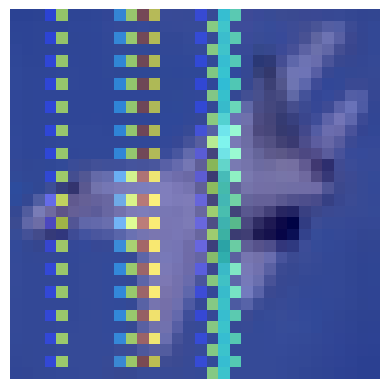

In [12]:
plt.imshow(img)
plt.imshow(gradcam, cmap='jet', alpha=0.5)
plt.axis('off')
plt.show()